# K-Means Clustering Polutan

Dokumen ini menjelaskan proses pengelompokan (clustering) area berdasarkan tingkat dan karakteristik polutan (dalam hal ini NO2). Setelah melakukan ekstraksi fitur (menggunakan TSFEL) pada data deret waktu polutan dari area Kwanyar dan digabungkan dengan data dari area milik teman sekelas.

Tujuan dari tahapan ini adalah untuk menemukan daerah-daerah mana saja yang memiliki karakteristik, tren, dan pola polusi yang serupa.

## 1. Implementasi K-Means dengan Python (Scikit-Learn)

Untuk mengimplementasikan rekomendasi di atas, kita dapat menggunakan bahasa pemrograman Python dengan *library* **Scikit-Learn** (`sklearn`). Library ini adalah standar industri yang sangat bagus dan stabil untuk pemodelan *Machine Learning* konvensional seperti PCA dan K-Means.

### 1.1 Evaluasi Jumlah Cluster (Elbow Method)

Untuk mengetahui berapa cluster yang paling optimal, kita menggunakan **Elbow Method**. Kita akan melatih model K-Means dengan variasi jumlah cluster (misalnya $K=2$ sampai $K=10$), lalu menghitung nilai inersia (jarak kuadrat rata-rata ke pusat cluster).

```python
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv('ekstraksi_fitur_no2.csv')
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

scaler = StandardScaler()
fitur_scaled = scaler.fit_transform(fitur)
fitur_pca = PCA(n_components=37).fit_transform(fitur_scaled)

inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(fitur_pca)
    inertia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Evaluasi Jumlah Cluster dengan Elbow Method')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inersia (Jarak Kuadrat)')
plt.grid(True)
plt.show()
```

1. CO

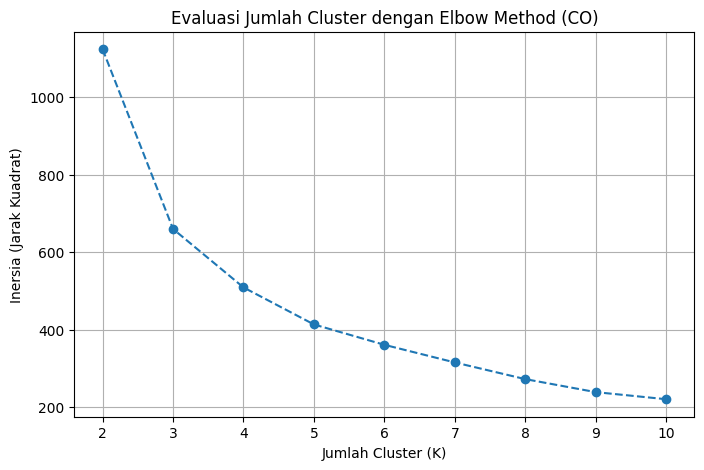

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv('ekstraksi_fitur_co.csv')
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

scaler = StandardScaler()
fitur_scaled = scaler.fit_transform(fitur)
fitur_pca = PCA(n_components=37).fit_transform(fitur_scaled)

inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(fitur_pca)
    inertia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Evaluasi Jumlah Cluster dengan Elbow Method (CO)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inersia (Jarak Kuadrat)')
plt.grid(True)
plt.show()

2. NO2

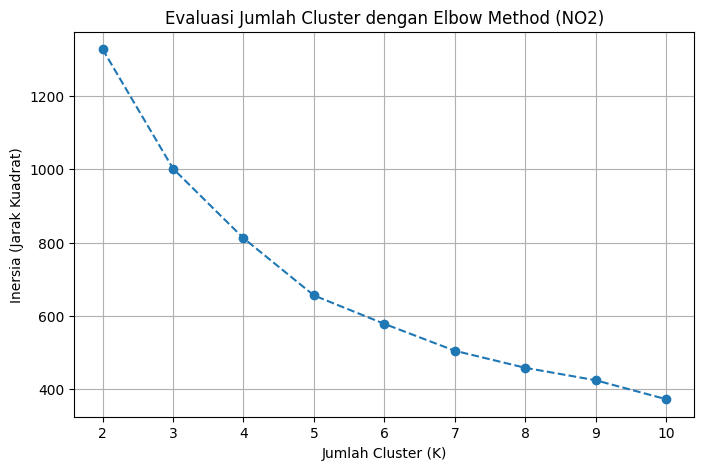

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv('ekstraksi_fitur_no2.csv')
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

scaler = StandardScaler()
fitur_scaled = scaler.fit_transform(fitur)
fitur_pca = PCA(n_components=37).fit_transform(fitur_scaled)

inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(fitur_pca)
    inertia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Evaluasi Jumlah Cluster dengan Elbow Method (NO2)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inersia (Jarak Kuadrat)')
plt.grid(True)
plt.show()

3. SO2

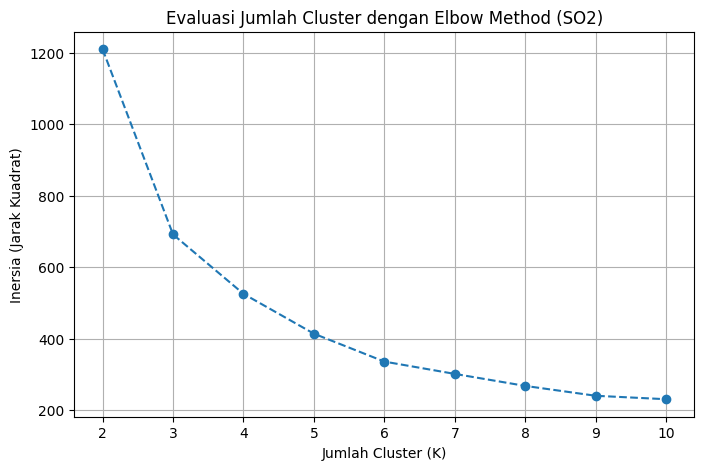

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv('ekstraksi_fitur_so2.csv')
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

scaler = StandardScaler()
fitur_scaled = scaler.fit_transform(fitur)
fitur_pca = PCA(n_components=37).fit_transform(fitur_scaled)

inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(fitur_pca)
    inertia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Evaluasi Jumlah Cluster dengan Elbow Method (SO2)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inersia (Jarak Kuadrat)')
plt.grid(True)
plt.show()

*Catatan: Anda akan melihat patahan siku (elbow) pada grafik di atas. Jika patahannya paling tajam di angka 6, maka $K=6$ adalah pilihan yang tepat.*

### 1.2 Visualisasi Scatter Plot PCA dan Profiling

Setelah menentukan menggunakan $K=6$, kita jalankan algoritma K-Means final. Kemudian kita membuat **Scatter Plot PCA** menggunakan PCA 1 dan PCA 2 untuk melihat apakah klaster terpisah dengan baik secara matematis.

```python
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Memuat Data
df = pd.read_csv('ekstraksi_fitur_no2.csv')
identitas = df[['id', 'nama', 'daerah']]
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

# 2. Standardisasi & PCA
scaler = StandardScaler()
fitur_pca = PCA(n_components=37).fit_transform(scaler.fit_transform(fitur))

# 3. K-Means (K=6)
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters = kmeans.fit_predict(fitur_pca)

df_hasil = identitas.copy()
df_hasil['Cluster'] = clusters

# 4. Visualisasi Scatter Plot
plt.figure(figsize=(15, 7))
sns.scatterplot(x=df_hasil['daerah'], y=df_hasil['Cluster'], hue=df_hasil['Cluster'], palette='tab10', s=100)
plt.title('Scatter Plot Persebaran Daerah per Cluster (NAMA_POLUTAN)')
plt.xlabel('Nama Daerah')
plt.ylabel('Cluster')
plt.xticks(rotation=90)
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# 5. Menampilkan profil klaster berdasarkan daerah (Top 3 per klaster)
profil_daerah = df_hasil.groupby(['Cluster', 'daerah']).size().reset_index(name='Jumlah')
top_3_per_cluster = profil_daerah.sort_values(by=['Cluster', 'Jumlah'], ascending=[True, False]).groupby('Cluster').head(3)
print(top_3_per_cluster)
```

1. CO

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Memuat Data
df = pd.read_csv('ekstraksi_fitur_co.csv')
identitas = df[['id', 'nama', 'daerah']]
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

# 2. Standardisasi & PCA
scaler = StandardScaler()
fitur_pca = PCA(n_components=37).fit_transform(scaler.fit_transform(fitur))

# 3. K-Means (K=4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(fitur_pca)

df_hasil = identitas.copy()
df_hasil['Cluster'] = clusters

# 4. Visualisasi Scatter Plot
plt.figure(figsize=(15, 7))
sns.scatterplot(x=df_hasil['daerah'], y=df_hasil['Cluster'], hue=df_hasil['Cluster'], palette='tab10', s=100)
plt.title('Scatter Plot Persebaran Daerah per Cluster (CO)')
plt.xlabel('Nama Daerah')
plt.ylabel('Cluster')
plt.xticks(rotation=90)
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# 5. Menampilkan profil klaster berdasarkan daerah (Top 3 per klaster)
profil_daerah = df_hasil.groupby(['Cluster', 'daerah']).size().reset_index(name='Jumlah')
top_3_per_cluster = profil_daerah.sort_values(by=['Cluster', 'Jumlah'], ascending=[True, False]).groupby('Cluster').head(3)
print(top_3_per_cluster)

ModuleNotFoundError: No module named 'seaborn'

2. NO2

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Memuat Data
df = pd.read_csv('ekstraksi_fitur_no2.csv')
identitas = df[['id', 'nama', 'daerah']]
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

# 2. Standardisasi & PCA
scaler = StandardScaler()
fitur_pca = PCA(n_components=37).fit_transform(scaler.fit_transform(fitur))

# 3. K-Means (K=6)
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters = kmeans.fit_predict(fitur_pca)

df_hasil = identitas.copy()
df_hasil['Cluster'] = clusters

# 4. Visualisasi Scatter Plot
plt.figure(figsize=(15, 7))
sns.scatterplot(x=df_hasil['daerah'], y=df_hasil['Cluster'], hue=df_hasil['Cluster'], palette='tab10', s=100)
plt.title('Scatter Plot Persebaran Daerah per Cluster (NO2)')
plt.xlabel('Nama Daerah')
plt.ylabel('Cluster')
plt.xticks(rotation=90)
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# 5. Menampilkan profil klaster berdasarkan daerah (Top 3 per klaster)
profil_daerah = df_hasil.groupby(['Cluster', 'daerah']).size().reset_index(name='Jumlah')
top_3_per_cluster = profil_daerah.sort_values(by=['Cluster', 'Jumlah'], ascending=[True, False]).groupby('Cluster').head(3)
print(top_3_per_cluster)

3. SO2

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Memuat Data
df = pd.read_csv('ekstraksi_fitur_so2.csv')
identitas = df[['id', 'nama', 'daerah']]
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

# 2. Standardisasi & PCA
scaler = StandardScaler()
fitur_pca = PCA(n_components=37).fit_transform(scaler.fit_transform(fitur))

# 3. K-Means (K=6)
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters = kmeans.fit_predict(fitur_pca)

df_hasil = identitas.copy()
df_hasil['Cluster'] = clusters

# 4. Visualisasi Scatter Plot
plt.figure(figsize=(15, 7))
sns.scatterplot(x=df_hasil['daerah'], y=df_hasil['Cluster'], hue=df_hasil['Cluster'], palette='tab10', s=100)
plt.title('Scatter Plot Persebaran Daerah per Cluster (SO2)')
plt.xlabel('Nama Daerah')
plt.ylabel('Cluster')
plt.xticks(rotation=90)
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# 5. Menampilkan profil klaster berdasarkan daerah (Top 3 per klaster)
profil_daerah = df_hasil.groupby(['Cluster', 'daerah']).size().reset_index(name='Jumlah')
top_3_per_cluster = profil_daerah.sort_values(by=['Cluster', 'Jumlah'], ascending=[True, False]).groupby('Cluster').head(3)
print(top_3_per_cluster)

---

## 2. Alur Kerja (Workflow) Clustering KNIME

```{figure} ./img/alur.png
---
name: workflow-kmeans
align: center
width: 70%
---
Visualisasi Alur Kerja (Workflow) K-Means pada KNIME
```

Berdasarkan diagram *workflow* KNIME yang digunakan, berikut adalah penjelasan dari tahapan yang dilakukan:

1. **PostgreSQL Connector $\rightarrow$ DB Table Selector $\rightarrow$ DB Reader**: 
   Rangkaian node ini berfungsi untuk melakukan koneksi ke sistem basis data (PostgreSQL), memilih tabel yang menyimpan data hasil ekstraksi fitur gabungan dari seluruh daerah, dan membaca data tersebut untuk diproses lebih lanjut.

2. **PCA (Principal Component Analysis)**:
   Karena hasil ekstraksi fitur dari data deret waktu biasanya menghasilkan puluhan hingga ratusan kolom (dimensi tinggi), PCA sangat penting digunakan di sini. PCA berfungsi mereduksi dimensi dengan memampatkan fitur-fitur yang banyak tersebut menjadi beberapa komponen utama (*Principal Components*) saja tanpa menghilangkan informasi atau varians penting dari data aslinya. Hal ini membuat algoritma K-Means bekerja jauh lebih cepat, ringan, dan terhindar dari *Curse of Dimensionality*.

3. **k-Means**:
   Ini adalah algoritma *machine learning unsupervised* yang digunakan untuk mengelompokkan data. Algoritma ini akan membagi daerah-daerah ke dalam $K$ buah kelompok (cluster) berdasarkan kedekatan jarak matematis dari fitur-fitur PCA-nya. Daerah yang memiliki kedekatan pola polusi yang mirip akan ditempatkan pada cluster yang sama.

4. **Scatter Plot**:
   Node ini digunakan untuk memvisualisasikan hasil dari K-Means sehingga kita bisa melihat titik persebaran setiap daerah masuk ke cluster mana saja.

---

## 3. Interpretasi Hasil Clustering (Scatter Plot KNIME)

Berikut adalah visualisasi *Scatter Plot* dari hasil K-Means Clustering yang dilakukan di KNIME untuk masing-masing polutan (NO2, CO, dan SO2), beserta interpretasinya. Sumbu X menunjukkan nama daerah, sedangkan Sumbu Y menunjukkan penetapan Cluster.

### 3.1 Polutan CO (K = 4)

```{figure} ./img/scatter_plot_CO.png
---
name: scatterplot-kmeans-co
align: center
width: 70%
---
Visualisasi Scatter Plot Hasil Clustering K-Means (CO)
```

Untuk polutan **CO**, pembagian klaster yang optimal (berdasarkan *Elbow Method*) adalah **4 kelompok (cluster_0 hingga cluster_3)**. Jumlah klaster yang lebih sedikit dibandingkan NO2 ini menunjukkan bahwa variasi karakteristik polusi karbon monoksida antar daerah tidak terlalu ekstrem. 

Beberapa wawasan (insight) yang bisa diambil dari plot CO:
* **Dominasi Cluster 0**: Sama seperti kasus NO2, terdapat satu cluster yang sangat mendominasi (Cluster 0). Banyak daerah yang memiliki pola fluktuasi gas CO yang serupa (seperti Kwanyar, Asemrowo, dan Jombang). Hal ini menunjukkan kondisi tren penyebaran CO paling standar di area observasi.
* **Karakteristik Spesifik Wilayah Kamal**: Sekali lagi, daerah sekitar Kamal (baik titik Banyuajuh maupun Bangkalan) memisahkan diri dan masuk ke dalam kelompok tersendiri secara terisolasi (Cluster 1 dan Cluster 2). Hal ini memperkuat dugaan bahwa wilayah Kamal memiliki aktivitas emisi lokal yang benar-benar berbeda dari wilayah lain.
* **Kesamaan Pola Minor**: Daerah seperti Cerme (Gresik), Wonoayu, dan Kalianget (Sumenep) menunjukkan kedekatan karakteristik penyebaran CO sehingga dikelompokkan ke dalam satu kelompok pinggiran yakni Cluster 3.

### 3.2 Polutan NO2 (K = 6)

```{figure} ./img/scatter_plot_NO2.png
---
name: scatterplot-kmeans-no2
align: center
width: 70%
---
Visualisasi Scatter Plot Hasil Clustering K-Means (NO2)
```

Berdasarkan visualisasi grafik untuk polutan **NO2**, algoritma K-Means telah membagi data menjadi **6 kelompok (cluster_0 hingga cluster_5)**.

Beberapa wawasan (insight) yang bisa diambil dari persebaran plot ini:
* **Persebaran Multipel pada Satu Daerah**: Beberapa daerah memiliki titik data yang menyebar di lebih dari satu cluster. Hal ini wajar terjadi apabila dataset dipecah dalam jendela waktu tertentu (misal per minggu atau per bulan). Artinya, karakteristik polusi di daerah tersebut cukup fluktuatif sehingga bisa menyerupai pola cluster A pada waktu tertentu, dan berubah mengikuti pola cluster B pada waktu lain.
* **Dominasi Cluster 4**: Cluster 4 tampaknya menjadi kondisi yang paling banyak dialami oleh berbagai daerah (titik paling padat merata secara horizontal), mulai dari Manyar, Gresik Kota, Sampang, Tuban, Ngawi, hingga Sidoarjo. Ini mengindikasikan adanya suatu **pola polusi dasar/umum** yang sering dialami oleh mayoritas daerah.
* **Anomali / Kondisi Spesifik**: **Cluster 5** terlihat sangat terisolasi dan pada grafik ini titiknya hanya muncul di daerah **Kamal, Banyuajuh**. Hal ini menjadi indikasi kuat bahwa Kamal memiliki karakteristik pergerakan polusi yang sangat unik dan spesifik pada titik observasi tersebut yang sama sekali tidak dialami oleh daerah-daerah lain dalam dataset.
* **Kesamaan Pola Minor**: Daerah seperti Cerme (Gresik) dan Widodaren (Ngawi) memiliki kesamaan karena sama-sama tercatat memiliki titik kondisi di **Cluster 3**.

### 3.3 Polutan SO2 (K = 6)

```{figure} ./img/scatter_plot_SO2.png
---
name: scatterplot-kmeans-so2
align: center
width: 70%
---
Visualisasi Scatter Plot Hasil Clustering K-Means (SO2)
```

Sama halnya dengan NO2, polutan **SO2** memiliki persebaran yang cukup kompleks sehingga algoritma membaginya secara optimal menjadi **6 kelompok (cluster_0 hingga cluster_5)**. Hal ini menunjukkan tingkat variasi konsentrasi sulfur dioksida yang cukup tinggi.

Beberapa wawasan (insight) yang bisa diambil dari plot SO2:
* **Penyebaran Utama (Cluster 1 & Cluster 4)**: Sebagian besar wilayah dikelompokkan ke dalam Cluster 1 (seperti Asemrowo, Jombang, Nganjuk) dan Cluster 4 (Gresik Kota, Cerme, Banyu Ajuh). Ini menandakan adanya dua profil dasar yang dominan dalam pergerakan SO2.
* **Pemisahan Karakteristik Kamal**: Titik observasi Kamal (Banyuajuh dan Bangkalan) secara konsisten menunjukkan hasil sebagai *outlier* atau anomali dengan menempati klaster terisolasi (Cluster 2 dan Cluster 3) yang terpisah dari gerombolan mayoritas.
* **Anomali Tunggal Wilayah Wonoayu**: Berbeda dengan CO dimana Wonoayu berada di kelompok minor bersama Cerme, pada kasus SO2 ini Wonoayu sepenuhnya terisolasi dan menempati Cluster 5 sendirian. Ini mengindikasikan adanya kejadian atau tren konsentrasi SO2 yang spesifik dan tajam di wilayah tersebut.